In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
%config InlineBackend.figure_format = "retina"


In [2]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)


def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
time_vec = np.copy(t)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

H = np.zeros((n_pts, 3))
H[:, 0] = v_inter
H[:, 1] = -v_mat[0, :]
H[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

P_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
P_noise = P_true + noise_scale * np.random.normal(size=P_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

P_true_noco = np.copy(P_true)
P_noise_noco = np.copy(P_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = P_true_noco[i, coseismic_idx] - P_true_noco[i, coseismic_idx - 1]
    P_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = P_noise_noco[i, coseismic_idx] - P_noise_noco[i, coseismic_idx - 1]
    P_noise_noco[i, coseismic_idx::] -= coseismic_step

In [3]:
def nnls_per_timestep(A, b_list):
    T = len(b_list)
    n = A.shape[1]
    x_est = np.zeros((T, n))

    for t in range(T):
        x_est[t], _ = nnls(A, b_list[t])

    return x_est


def smooth_nnls(A, b_list, alpha=1.0, max_iter=200, lr=1e-2):
    """
    Solve for x(t) by minimizing:

    Sum ||A x(t) - b(t)||^2 + alpha * Sum ||x(t+1) - x(t)||^2

    With the constraint: subject to x(t) >= 0 at all t.
    """
    nt = len(b_list)

    # Initialize x_est by solving NNLS at each time step individually.
    x_est = nnls_per_timestep(A, b_list)

    for i in range(max_iter):
        # Gradient storage
        grad = np.zeros_like(x_est)

        # Data fit gradient: ||A x(t) - b(t)||^2
        # - Derivative wrt x(t): 2 A^T (A x(t) - b(t))
        for t in range(nt):
            residual = A.dot(x_est[t]) - b_list[t]
            grad[t] += 2.0 * A.T.dot(residual)

        # Time smoothness gradient: alpha * Sum ||x(t+1) - x(t)||^2
        # For ||x_{t+1} - x_t||^2:
        # - Derivative wrt x(t): 2 (x(t) - x(t+1))
        # - Derivative wrt x(t+1): 2 (x(t+1) - x(t))
        for t in range(nt - 1):
            diff = x_est[t] - x_est[t + 1]  # x(t) - x(t+1)
            grad[t] += alpha * 2.0 * diff
            grad[t + 1] -= alpha * 2.0 * diff

        # Gradient step with learning rate
        x_est = x_est - lr * grad

        # Project onto x >= 0
        np.clip(x_est, 0, None, out=x_est)

        if i % 50 == 0 or i == max_iter - 1:
            # Compute current objective
            obj_data = 0.0
            obj_smooth = 0.0
            for t in range(nt):
                res = A.dot(x_est[t]) - b_list[t]
                obj_data += np.sum(res**2)
            for t2 in range(nt - 1):
                diff = x_est[t2 + 1] - x_est[t2]
                obj_smooth += np.sum(diff**2)
            obj = obj_data + alpha * obj_smooth
            print(f"{i=:4d}: {obj=:.4f}, {obj_data=:.4f}, {obj_smooth=:.4f}")

    return x_est


# Time smoothing weight
alpha = 5.0

# Maximum number of iterations
max_iter = 300

# Learning rate
lr = 1e-3

# Package observation into a list of arrays for each time step
b_list = [_ for _ in P_noise_noco.T]

# Solve
x_tik = smooth_nnls(A, b_list, alpha=alpha, max_iter=max_iter, lr=lr)

i=   0: obj=1.1461, obj_data=0.1914, obj_smooth=0.1909
i=  50: obj=0.3197, obj_data=0.1937, obj_smooth=0.0252
i= 100: obj=0.2581, obj_data=0.1950, obj_smooth=0.0126
i= 150: obj=0.2452, obj_data=0.1956, obj_smooth=0.0099
i= 200: obj=0.2402, obj_data=0.1960, obj_smooth=0.0088
i= 250: obj=0.2374, obj_data=0.1963, obj_smooth=0.0082
i= 299: obj=0.2356, obj_data=0.1965, obj_smooth=0.0078


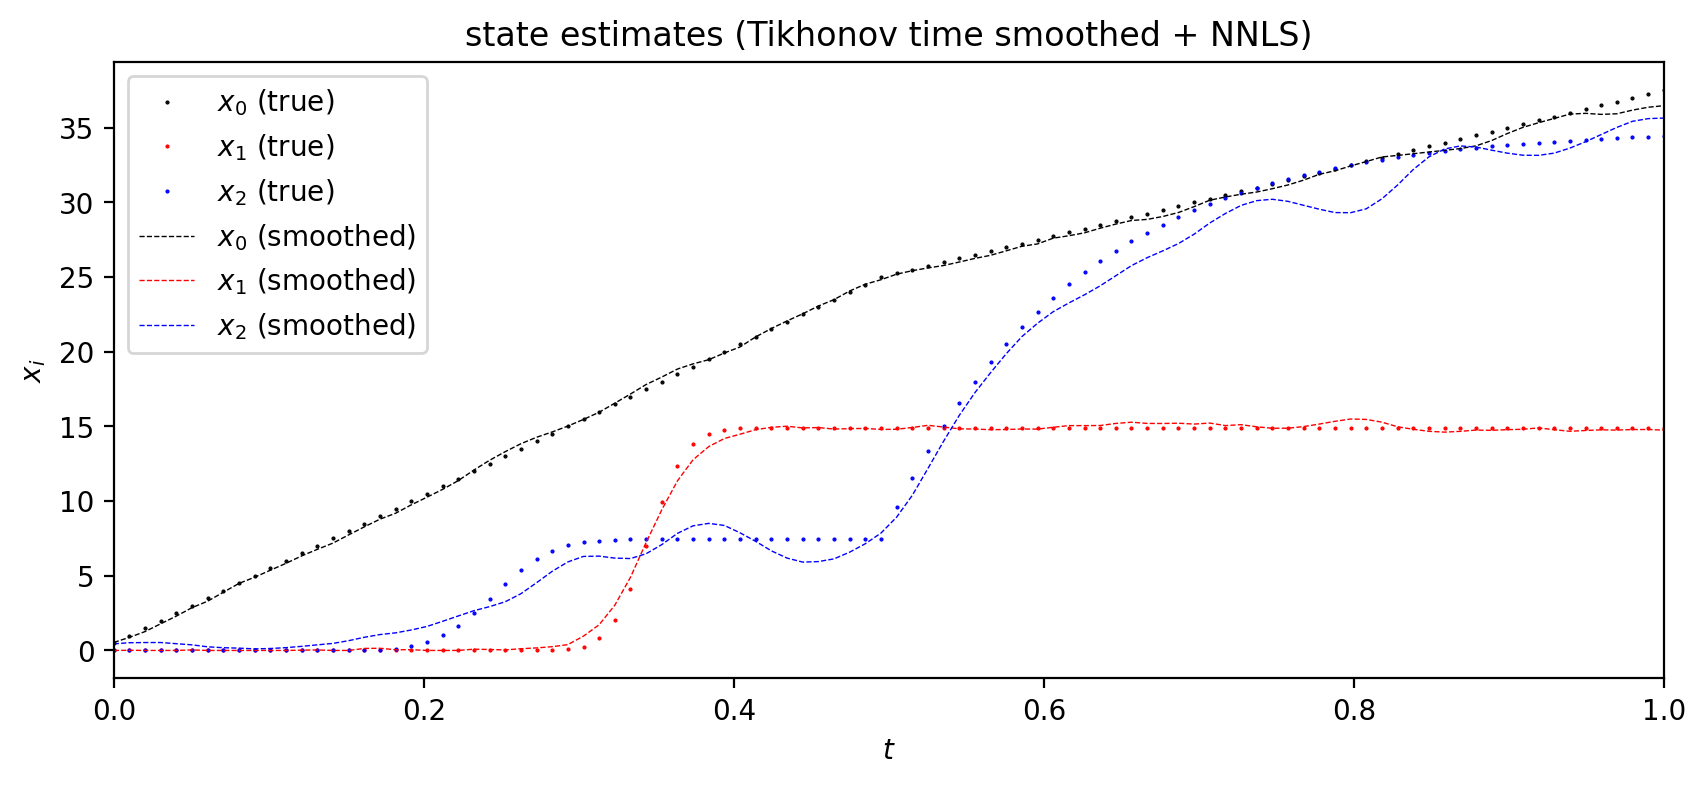

In [5]:
linewidth = 0.5
markersize = 1.0

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec,
    x0_noco,
    ".k",
    label="$x_0$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x1_noco,
    ".r",
    label="$x_1$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x2_noco,
    ".b",
    label="$x_2$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)

# plt.plot(
#     time_vec,
#     mixed_estimates[0, :] / dt / 100,
#     "-k",
#     label="$x_0$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )
# plt.plot(
#     time_vec,
#     mixed_estimates[1, :] / dt / 100,
#     "-r",
#     label="$x_1$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )
# plt.plot(
#     time_vec,
#     mixed_estimates[2, :] / dt / 100,
#     "-b",
#     label="$x_2$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )

plt.plot(
    time_vec,
    x_tik[:, 0] / dt,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x_tik[:, 1] / dt,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x_tik[:, 2] / dt,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (Tikhonov time smoothed + NNLS)")
plt.show()